# CNN 1D: prediccion del precio de viviendas

En este cuaderno uso una CNN 1D para estimar `SalePrice`.

Una CNN se usa normalmente en imagenes porque puede encontrar patrones cercanos, por ejemplo bordes, formas o texturas. En este caso no trabajo con imagenes, sino con datos de viviendas. Por eso la CNN 1D se usa como una adaptacion para trabajar con las caracteristicas ya procesadas.

El archivo `train1.csv` ya contiene viviendas con precio y viviendas sin precio. Las que tienen `SalePrice` se separan en **70 % entrenamiento, 15 % validacion y 15 % prueba interna**. Las viviendas sin precio se dejan aparte para predecir al final.

La CNN base se mantiene como estaba: Conv1D(32), Conv1D(16), Flatten, Dense(32), Dropout(0.1) y una salida con Softplus. Tambien se mantiene Adam con learning rate `0.0003`, MSE, MAE y EarlyStopping.

Importante: las columnas no son una serie temporal ni una imagen. La CNN se mantiene porque es el modelo que se esta probando en este trabajo.


## 1. Instalar las librerias


In [1]:
%pip -q install tensorflow pandas numpy matplotlib scikit-learn


## 2. Importar las librerias


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

SEMILLA = 42
keras.utils.set_random_seed(SEMILLA)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 3. Cargar el dataset

Se carga `train1.csv` y se muestran algunas filas para revisar que los datos esten bien.


In [4]:
# Carga el archivo unido desde tu computadora cuando Colab lo solicite.
from google.colab import files
if not Path('train1.csv').exists():
    archivos_cargados = files.upload()
assert Path('train1.csv').exists(), 'Carga el archivo con el nombre train1.csv.'


In [6]:

df = pd.read_csv('train1.csv', keep_default_na=False, na_values=['', 'NA'])
objetivo = 'SalePrice'
assert objetivo in df, 'train1.csv debe incluir la columna SalePrice.'
assert (df.loc[df[objetivo].notna(), objetivo] > 0).all()
assert df['Id'].notna().all() and df['Id'].is_unique
print('Tabla cargada:', df.shape)
print('Viviendas con precio:', df[objetivo].notna().sum())
print('Viviendas sin precio:', df[objetivo].isna().sum())
display(df.head())


Tabla cargada: (2919, 81)
Viviendas con precio: 1460
Viviendas sin precio: 1459


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


## 4. Revisar faltantes y preparar las variables

`Id` solo identifica cada vivienda y `SalePrice` es lo que se quiere predecir, por eso no se usan como variables de entrada.

Los datos faltantes se tratan segun el tipo de columna. Los numeros se rellenan con la mediana del entrenamiento y las categorias faltantes reciben una categoria. Luego las variables categoricas se convierten con one-hot encoding.

Todo el preprocesamiento se aprende solo con entrenamiento para no usar informacion de validacion o prueba antes de tiempo.


In [7]:
variables = [c for c in df.columns if c not in ['Id', objetivo]]
display(df[variables].isna().sum().loc[lambda s: s > 0].sort_values(ascending=False).to_frame('faltantes'))
datos = df.copy()
datos['MSSubClass'] = datos['MSSubClass'].map(lambda v: str(int(v)) if pd.notna(v) else np.nan)
for columna in ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu']:
    datos[columna] = datos[columna].fillna('Ausente')

sin_sotano = datos['TotalBsmtSF'].eq(0) & datos['BsmtQual'].isna()
sin_garaje = datos['GarageArea'].eq(0) & datos['GarageType'].isna()
for columna in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    datos.loc[sin_sotano, columna] = datos.loc[sin_sotano, columna].fillna('Ausente')
for columna in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    datos.loc[sin_garaje, columna] = datos.loc[sin_garaje, columna].fillna('Ausente')

numericas = datos[variables].select_dtypes(include=np.number).columns.tolist()
categoricas = [c for c in variables if c not in numericas]
datos[numericas] = datos[numericas].replace([np.inf, -np.inf], np.nan)
print('Variables numéricas:', len(numericas), '| Categóricas:', len(categoricas))


,faltantes
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
FireplaceQu,1420
LotFrontage,486
GarageQual,159
GarageFinish,159
GarageYrBlt,159
GarageCond,159


Variables numéricas: 35 | Categóricas: 44


## 5. Division 70/15/15

Las viviendas que si tienen precio se dividen en entrenamiento, validacion y prueba interna. Las viviendas sin precio quedan aparte para la prediccion final.


In [8]:
con_precio = datos.loc[datos[objetivo].notna()].copy()
sin_precio = datos.loc[datos[objetivo].isna()].copy()
n_reserva = len(con_precio) - round(len(con_precio) * 0.70)
entrenamiento, reserva = train_test_split(con_precio, test_size=n_reserva, random_state=SEMILLA)
validacion, prueba = train_test_split(reserva, test_size=len(reserva) // 2, random_state=SEMILLA)
assert set(entrenamiento.Id).isdisjoint(validacion.Id)
assert set(entrenamiento.Id).isdisjoint(prueba.Id)
assert set(validacion.Id).isdisjoint(prueba.Id)
assert len(entrenamiento) + len(validacion) + len(prueba) == len(con_precio)
for nombre, parte in [('Entrenamiento', entrenamiento), ('Validación', validacion),
                      ('Prueba interna', prueba), ('Por predecir', sin_precio)]:
    print(f'{nombre}: {len(parte)} viviendas')


Entrenamiento: 1022 viviendas
Validación: 219 viviendas
Prueba interna: 219 viviendas
Por predecir: 1459 viviendas


## 6. Rellenar, codificar y escalar los datos


In [9]:
preprocesador = ColumnTransformer([
    ('numericas', Pipeline([
        ('relleno', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True)),
        ('escala', StandardScaler())
    ]), numericas),
    ('categoricas', Pipeline([
        ('relleno', SimpleImputer(strategy='constant', fill_value='Desconocido')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categoricas)
])
X_train_2d = preprocesador.fit_transform(entrenamiento[variables]).astype('float32')
X_val_2d = preprocesador.transform(validacion[variables]).astype('float32')
X_train = X_train_2d[..., np.newaxis]
X_val = X_val_2d[..., np.newaxis]
y_train = entrenamiento[objetivo].to_numpy(dtype='float32')
y_val = validacion[objetivo].to_numpy(dtype='float32')

# Escalar la respuesta por una constante positiva facilita entrenar sin
# cambiar la salida softplus ni introducir precios negativos.
# Esta constante procede unicamente del entrenamiento.
escala_precio = float(y_train.mean())
y_train_escalado = y_train / escala_precio
y_val_escalado = y_val / escala_precio
assert np.isfinite(X_train).all() and np.isfinite(X_val).all()
print('Forma de entrenamiento:', X_train.shape)
print('Forma de validación:', X_val.shape)
print('Escala del precio:', round(escala_precio, 2))


Forma de entrenamiento: (1022, 316, 1)
Forma de validación: (219, 316, 1)
Escala del precio: 181312.69


## 7. CNN 1D base

Esta es la CNN original del cuaderno. No se cambia su estructura ni sus parametros principales.

La salida usa `softplus` para obtener valores positivos. Durante el entrenamiento el precio se divide entre la media del entrenamiento para que sea mas facil aprender, y al predecir se vuelve a la escala original.


In [10]:
keras.utils.set_random_seed(SEMILLA)
modelo_cnn = keras.Sequential([
    keras.Input(shape=(X_train.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu'),
    layers.Conv1D(filters=16, kernel_size=3, padding='causal', activation='relu'),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1, activation='softplus')
])
modelo_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),
                   loss='mse', metrics=['mae'])
modelo_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 316, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 316, 16)        │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5056)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       161,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,537 (638.82 KB)

 Trainable params: 163,537 (638.82 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenar la CNN base

Se usa EarlyStopping para detener el entrenamiento cuando el MAE de validacion deja de mejorar. Al final se recuperan los pesos de la mejor epoca.


In [11]:
parada_temprana = keras.callbacks.EarlyStopping(
    monitor='val_mae', mode='min', patience=15, restore_best_weights=True)
historial = modelo_cnn.fit(
    X_train, y_train_escalado, validation_data=(X_val, y_val_escalado),
    epochs=150, batch_size=64, shuffle=True,
    callbacks=[parada_temprana], verbose=2)


Epoch 1/150
16/16 - 2s - 153ms/step - loss: 0.1702 - mae: 0.2927 - val_loss: 0.0950 - val_mae: 0.2006
Epoch 2/150
16/16 - 0s - 29ms/step - loss: 0.0689 - mae: 0.1618 - val_loss: 0.0356 - val_mae: 0.1284
Epoch 3/150
16/16 - 1s - 38ms/step - loss: 0.0499 - mae: 0.1325 - val_loss: 0.0257 - val_mae: 0.1109
Epoch 4/150
16/16 - 0s - 29ms/step - loss: 0.0402 - mae: 0.1191 - val_loss: 0.0225 - val_mae: 0.1002
Epoch 5/150
16/16 - 0s - 28ms/step - loss: 0.0355 - mae: 0.1168 - val_loss: 0.0209 - val_mae: 0.0996
Epoch 6/150
16/16 - 0s - 28ms/step - loss: 0.0319 - mae: 0.1112 - val_loss: 0.0203 - val_mae: 0.0998
Epoch 7/150
16/16 - 1s - 38ms/step - loss: 0.0287 - mae: 0.1098 - val_loss: 0.0192 - val_mae: 0.0986
Epoch 8/150
16/16 - 1s - 44ms/step - loss: 0.0281 - mae: 0.1065 - val_loss: 0.0182 - val_mae: 0.0961
Epoch 9/150
16/16 - 1s - 47ms/step - loss: 0.0297 - mae: 0.1051 - val_loss: 0.0207 - val_mae: 0.1003
Epoch 10/150
16/16 - 1s - 82ms/step - loss: 0.0278 - mae: 0.1089 - val_loss: 0.0197 - val_

## 9. Evaluar entrenamiento y validacion


In [12]:
def predecir_precio(X):
    return modelo_cnn.predict(X, verbose=0).ravel() * escala_precio

def metricas(y_real, prediccion):
    return {
        'MAE': mean_absolute_error(y_real, prediccion),
        'RMSE': np.sqrt(mean_squared_error(y_real, prediccion)),
        'R2': r2_score(y_real, prediccion)
    }

pred_train = predecir_precio(X_train)
pred_val = predecir_precio(X_val)
mejor_epoca = int(np.argmin(historial.history['val_mae']) + 1)
resultados = {
    'CNN entrenamiento': metricas(y_train, pred_train),
    'CNN validación': metricas(y_val, pred_val),
    'Media entrenamiento → validación': metricas(y_val, np.full(len(y_val), y_train.mean()))
}
print('Mejor época:', mejor_epoca)
display(pd.DataFrame(resultados).T.round(3))


Mejor época: 11


,MAE,RMSE,R2
CNN entrenamiento,14995.054,25004.332,0.896
CNN validación,17325.531,24831.293,0.902
Media entrenamiento → validación,59903.184,79374.370,-0.003


### 9.1 Comparar precios reales y predichos en validacion


In [13]:
comparacion_cnn = pd.DataFrame({
    "Id": validacion["Id"].to_numpy(),
    "Precio_real": y_val,
    "Precio_predicho": pred_val
})

comparacion_cnn["Error_absoluto"] = abs(
    comparacion_cnn["Precio_real"]
    - comparacion_cnn["Precio_predicho"]
)

comparacion_cnn["Error_porcentual"] = (
    comparacion_cnn["Error_absoluto"]
    / comparacion_cnn["Precio_real"]
) * 100

display(comparacion_cnn.head(20).round(2))





,Id,Precio_real,Precio_predicho,Error_absoluto,Error_porcentual
0,366,147000.0,107100.382812,39899.621094,27.139999
1,1332,132500.0,124863.609375,7636.390137,5.760000
2,620,305000.0,320135.906250,15135.910156,4.960000
3,1059,335000.0,350602.031250,15602.030273,4.660000
4,82,153500.0,152894.734375,605.270020,0.390000
5,1175,239000.0,222619.812500,16380.169922,6.850000
6,222,200000.0,200544.140625,544.140015,0.270000
7,673,165000.0,180014.953125,15014.950195,9.100000
8,180,100000.0,111939.750000,11939.750000,11.940000
9,209,277000.0,250541.062500,26458.939453,9.550000


In [14]:
# Ordenar por mayor error absoluto
mayores_errores = comparacion_cnn.sort_values(
    by="Error_absoluto",
    ascending=False
)

# Mostrar los 20 errores mas grandes
display(mayores_errores.head(20).round(2))

,Id,Precio_real,Precio_predicho,Error_absoluto,Error_porcentual
215,1244,465000.0,336664.843750,128335.156250,27.600000
109,775,395000.0,278151.218750,116848.781250,29.580000
143,582,253293.0,338933.625000,85640.656250,33.810001
139,584,325000.0,249934.046875,75065.968750,23.100000
185,592,451950.0,376936.531250,75013.468750,16.600000
124,662,402000.0,329294.500000,72705.500000,18.090000
63,176,243000.0,178800.859375,64199.140625,26.420000
210,799,485000.0,425094.562500,59905.441406,12.350000
47,31,40000.0,95403.656250,55403.660156,138.509995
170,463,62383.0,114183.656250,51800.660156,83.040001


## 10. Curvas y resultados de validacion

El MAE muestra el error promedio en el precio. El RMSE castiga mas los errores grandes y R2 indica que tan bien se ajustan las predicciones.

Primero se mantiene la grafica original de MAE y luego se agrega la curva de Loss porque tambien sirve para revisar como fue el entrenamiento.


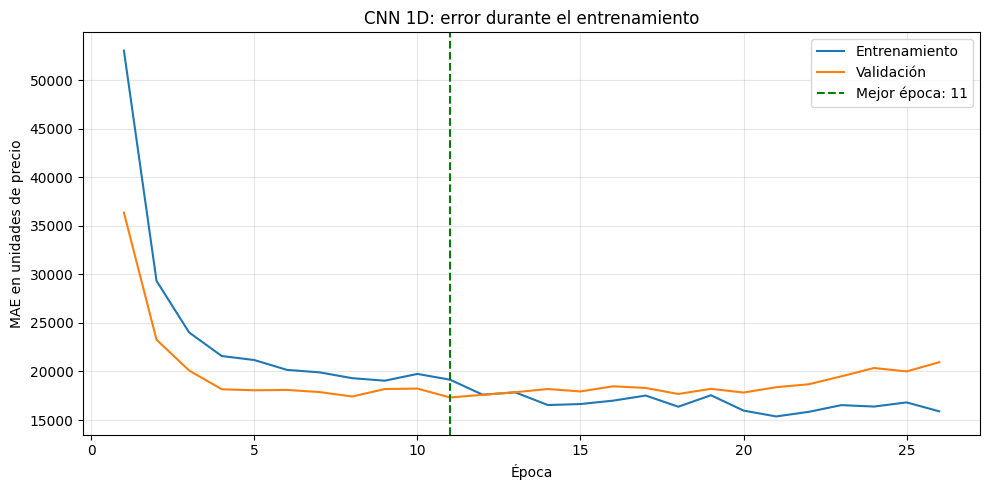

,Id,Precio_real,Precio_predicho,Error_absoluto
0,366,147000.0,107100.382812,39899.621094
1,1332,132500.0,124863.609375,7636.390137
2,620,305000.0,320135.906250,15135.910156
3,1059,335000.0,350602.031250,15602.030273
4,82,153500.0,152894.734375,605.270020
5,1175,239000.0,222619.812500,16380.169922
6,222,200000.0,200544.140625,544.140015
7,673,165000.0,180014.953125,15014.950195
8,180,100000.0,111939.750000,11939.750000
9,209,277000.0,250541.062500,26458.939453


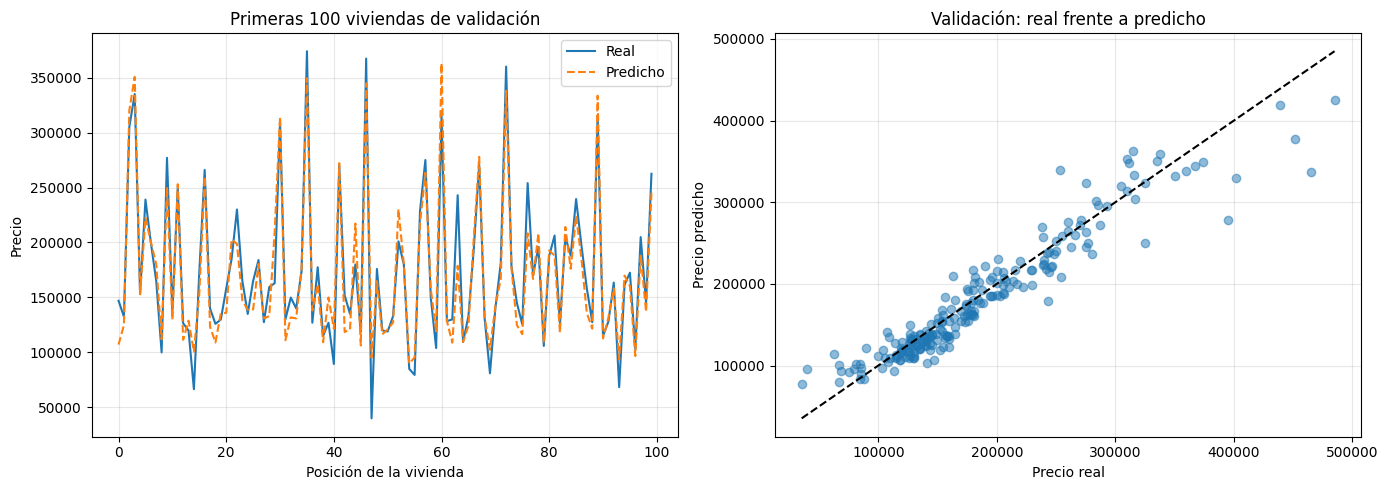

In [15]:
epocas = np.arange(1, len(historial.history['mae']) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epocas, np.array(historial.history['mae']) * escala_precio, label='Entrenamiento')
plt.plot(epocas, np.array(historial.history['val_mae']) * escala_precio, label='Validación')
plt.axvline(mejor_epoca, color='green', linestyle='--', label=f'Mejor época: {mejor_epoca}')
plt.xlabel('Época'); plt.ylabel('MAE en unidades de precio')
plt.title('CNN 1D: error durante el entrenamiento')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

comparacion_val = pd.DataFrame({'Id': validacion.Id.to_numpy(),
                               'Precio_real': y_val, 'Precio_predicho': pred_val})
comparacion_val['Error_absoluto'] = abs(comparacion_val.Precio_real - comparacion_val.Precio_predicho)
display(comparacion_val.head(20).round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
muestra = comparacion_val.head(100)
axes[0].plot(muestra.Precio_real.to_numpy(), label='Real')
axes[0].plot(muestra.Precio_predicho.to_numpy(), '--', label='Predicho')
axes[0].set(xlabel='Posición de la vivienda', ylabel='Precio', title='Primeras 100 viviendas de validación')
axes[0].legend()
axes[1].scatter(y_val, pred_val, alpha=0.5)
limites = [min(y_val.min(), pred_val.min()), max(y_val.max(), pred_val.max())]
axes[1].plot(limites, limites, 'k--')
axes[1].set(xlabel='Precio real', ylabel='Precio predicho', title='Validación: real frente a predicho')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



### 10.1 Curva de Loss

Esta grafica usa el mismo entrenamiento de la CNN base. No vuelve a entrenar el modelo.


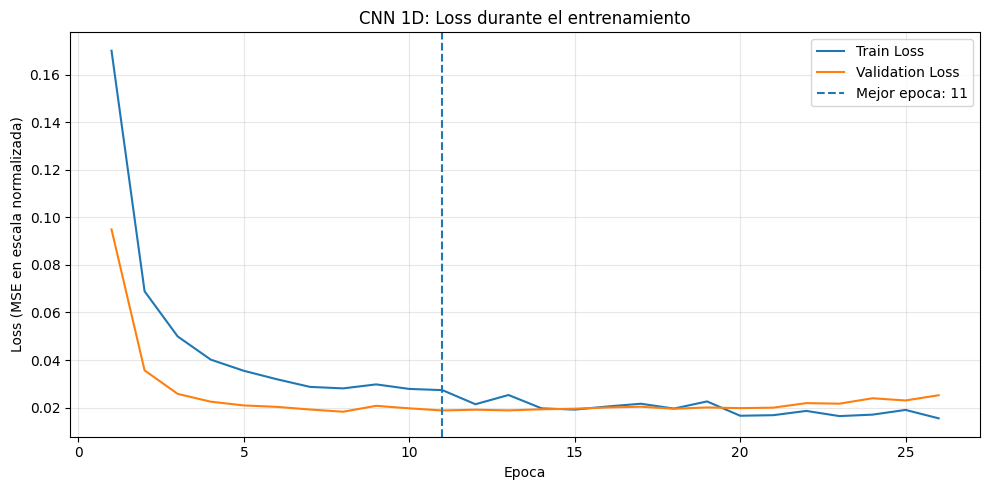

In [16]:
epocas_loss = np.arange(1, len(historial.history['loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epocas_loss, historial.history['loss'], label='Train Loss')
plt.plot(epocas_loss, historial.history['val_loss'], label='Validation Loss')
plt.axvline(mejor_epoca, linestyle='--', label=f'Mejor epoca: {mejor_epoca}')
plt.xlabel('Epoca')
plt.ylabel('Loss (MSE en escala normalizada)')
plt.title('CNN 1D: Loss durante el entrenamiento')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 10.2 Experimento corto con Dropout

La CNN base ya usa `Dropout(0.1)`. Para revisar si ayuda, se entrena otra CNN igual pero sin Dropout.

Este experimento usa solo entrenamiento y validacion. No reemplaza `modelo_cnn` y no cambia la evaluacion original de prueba.


In [17]:
def crear_modelo_experimento(learning_rate=0.0003, dropout=0.1):
    keras.utils.set_random_seed(SEMILLA)

    capas_modelo = [
        keras.Input(shape=(X_train.shape[1], 1)),
        layers.Conv1D(filters=32, kernel_size=3, padding='causal', activation='relu'),
        layers.Conv1D(filters=16, kernel_size=3, padding='causal', activation='relu'),
        layers.Flatten(),
        layers.Dense(32, activation='relu')
    ]

    if dropout > 0:
        capas_modelo.append(layers.Dropout(dropout))

    capas_modelo.append(layers.Dense(1, activation='softplus'))

    modelo = keras.Sequential(capas_modelo)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return modelo


def entrenar_experimento(modelo):
    parada = keras.callbacks.EarlyStopping(
        monitor='val_mae',
        mode='min',
        patience=15,
        restore_best_weights=True
    )

    historia = modelo.fit(
        X_train,
        y_train_escalado,
        validation_data=(X_val, y_val_escalado),
        epochs=150,
        batch_size=64,
        shuffle=True,
        callbacks=[parada],
        verbose=0
    )
    return historia


In [18]:
modelo_sin_dropout = crear_modelo_experimento(
    learning_rate=0.0003,
    dropout=0.0
)
historial_sin_dropout = entrenar_experimento(modelo_sin_dropout)

pred_val_sin_dropout = (
    modelo_sin_dropout.predict(X_val, verbose=0).ravel() * escala_precio
)

tabla_dropout = pd.DataFrame([
    {
        'Modelo': 'CNN base - Dropout 0.1',
        'Val_MAE': mean_absolute_error(y_val, pred_val),
        'Mejor_epoca': mejor_epoca
    },
    {
        'Modelo': 'CNN sin Dropout',
        'Val_MAE': mean_absolute_error(y_val, pred_val_sin_dropout),
        'Mejor_epoca': int(np.argmin(historial_sin_dropout.history['val_mae']) + 1)
    }
])

display(tabla_dropout.round(3))


,Modelo,Val_MAE,Mejor_epoca
0,CNN base - Dropout 0.1,17325.531,11
1,CNN sin Dropout,16276.333,50


### 10.3 Comparar Learning Rate

Se mantiene `0.0003` como referencia porque es el learning rate de la CNN base. Solo se prueban `0.0005` y `0.001` para ver si mejoran el MAE de validacion.

No se agrega scheduler porque no es necesario para esta comparacion y la guia de imagenes solo se esta usando como referencia.


,Learning_rate,Val_MAE,Mejor_epoca
0,0.000,15775.870,55
1,0.001,16284.634,24
2,0.000,17325.531,11


Mejor learning rate segun validacion: 0.0005


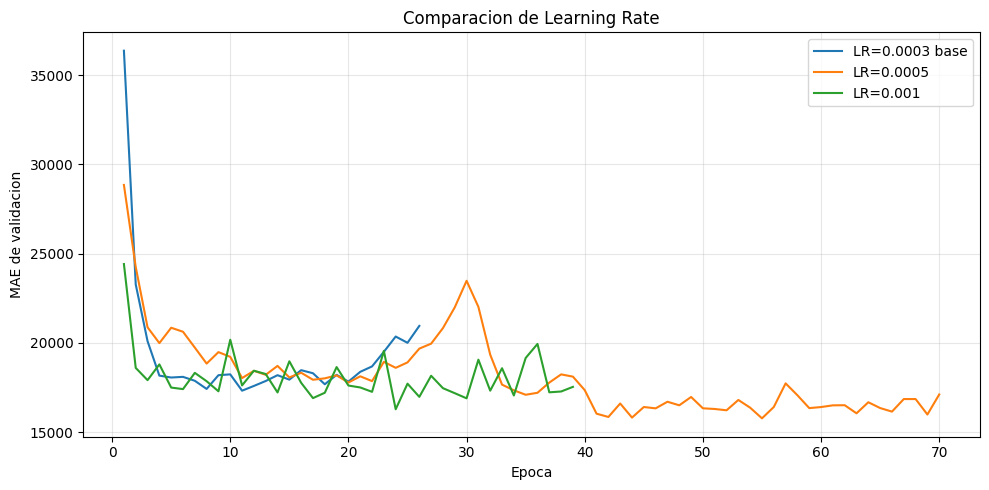

In [19]:
resultados_lr = [
    {
        'Learning_rate': 0.0003,
        'Val_MAE': mean_absolute_error(y_val, pred_val),
        'Mejor_epoca': mejor_epoca
    }
]

historias_lr = {
    '0.0003 base': historial
}

for lr in [0.0005, 0.001]:
    modelo_lr = crear_modelo_experimento(
        learning_rate=lr,
        dropout=0.1
    )
    historia_lr = entrenar_experimento(modelo_lr)

    pred_lr = modelo_lr.predict(X_val, verbose=0).ravel() * escala_precio

    resultados_lr.append({
        'Learning_rate': lr,
        'Val_MAE': mean_absolute_error(y_val, pred_lr),
        'Mejor_epoca': int(np.argmin(historia_lr.history['val_mae']) + 1)
    })

    historias_lr[str(lr)] = historia_lr

tabla_lr = pd.DataFrame(resultados_lr).sort_values('Val_MAE').reset_index(drop=True)
display(tabla_lr.round(3))

mejor_lr = float(tabla_lr.loc[0, 'Learning_rate'])
print(f'Mejor learning rate segun validacion: {mejor_lr}')

plt.figure(figsize=(10, 5))

for nombre, historia_lr in historias_lr.items():
    epocas_lr = np.arange(1, len(historia_lr.history['val_mae']) + 1)
    val_mae_precio = np.array(historia_lr.history['val_mae']) * escala_precio
    plt.plot(epocas_lr, val_mae_precio, label=f'LR={nombre}')

plt.xlabel('Epoca')
plt.ylabel('MAE de validacion')
plt.title('Comparacion de Learning Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Evaluar la prueba interna

Esta parte se mantiene igual que en el cuaderno base. La prueba interna no se usa para escoger learning rate ni para decidir cambios del modelo.

Por eso los experimentos anteriores solo comparan resultados de validacion.


,MAE,RMSE,R2
CNN entrenamiento,14995.054,25004.332,0.896
CNN validación,17325.531,24831.293,0.902
Media entrenamiento → validación,59903.184,79374.370,-0.003
CNN prueba interna,18109.268,33732.436,0.850
Media entrenamiento → prueba interna,59191.168,87517.443,-0.006


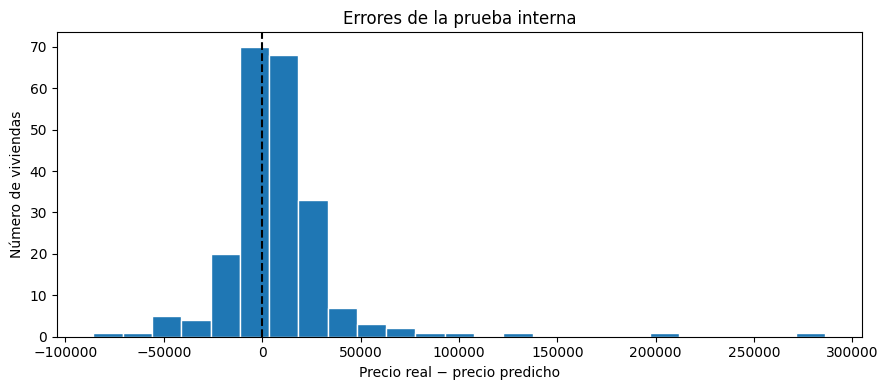

In [20]:
X_prueba = preprocesador.transform(prueba[variables]).astype('float32')[..., np.newaxis]
y_prueba = prueba[objetivo].to_numpy(dtype='float32')
pred_prueba = predecir_precio(X_prueba)
resultados['CNN prueba interna'] = metricas(y_prueba, pred_prueba)
resultados['Media entrenamiento → prueba interna'] = metricas(y_prueba, np.full(len(y_prueba), y_train.mean()))
tabla_metricas = pd.DataFrame(resultados).T
display(tabla_metricas.round(3))
plt.figure(figsize=(9, 4))
plt.hist(y_prueba - pred_prueba, bins=25, edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Precio real − precio predicho'); plt.ylabel('Número de viviendas')
plt.title('Errores de la prueba interna'); plt.tight_layout(); plt.show()


## 12. Analisis por rangos de precio

La CNN sigue siendo una regresion porque predice un precio numerico. Para tener una vista adicional, los precios se separan en `Bajo`, `Medio` y `Alto` usando limites calculados solo con entrenamiento.

Con esos rangos se puede mostrar accuracy, classification report, sensibilidad, especificidad y matriz de confusion. Estas metricas son complementarias. Para el precio exacto las metricas principales siguen siendo MAE, RMSE y R2.

No se usa ROC-AUC porque el modelo no entrega probabilidades de clases, sino un precio continuo.


Límite Bajo/Medio: 140,000.00
Límite Medio/Alto: 191,666.67

=== CLASSIFICATION REPORT: PRUEBA INTERNA ===
              precision    recall  f1-score   support

        Bajo     0.7925    0.9438    0.8615        89
       Medio     0.7407    0.5634    0.6400        71
        Alto     0.8305    0.8305    0.8305        59

    accuracy                         0.7900       219
   macro avg     0.7879    0.7792    0.7773       219
weighted avg     0.7859    0.7900    0.7814       219

=== MATRIZ DE CONFUSIÓN ===


,Pred_Bajo,Pred_Medio,Pred_Alto
Real_Bajo,84,4,1
Real_Medio,22,40,9
Real_Alto,0,10,49


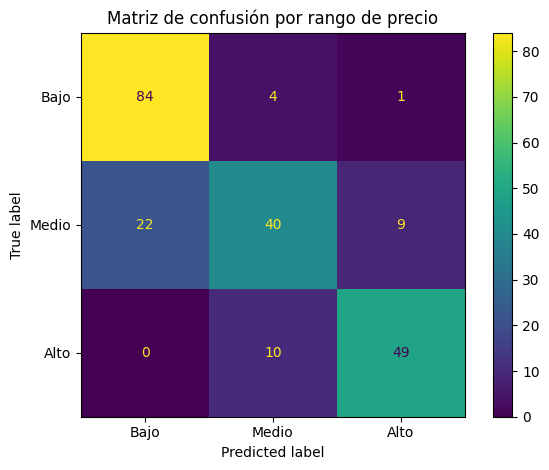

=== SENSIBILIDAD Y ESPECIFICIDAD ===


,Sensibilidad_Recall,Especificidad
Clase,,
Bajo,0.9438,0.8308
Medio,0.5634,0.9054
Alto,0.8305,0.9375


,Id,Precio_real,Precio_predicho,Clase_real,Clase_predicha,Clasificacion_correcta
0,1419,124000.0,114498.312500,Bajo,Bajo,True
1,45,141000.0,136755.062500,Medio,Bajo,False
2,589,143000.0,228693.859375,Medio,Alto,False
3,1049,115000.0,130800.976562,Bajo,Bajo,True
4,440,110000.0,122983.117188,Bajo,Bajo,True
5,652,108000.0,114858.703125,Bajo,Bajo,True
6,359,130000.0,121075.382812,Bajo,Bajo,True
7,423,113000.0,111975.703125,Bajo,Bajo,True
8,332,139000.0,132214.656250,Bajo,Bajo,True
9,210,145000.0,154361.546875,Medio,Medio,True


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Crear tres clases usando SOLO los precios de entrenamiento
limite_bajo, limite_alto = np.quantile(y_train, [1/3, 2/3])
CLASES = ['Bajo', 'Medio', 'Alto']

print(f'Límite Bajo/Medio: {limite_bajo:,.2f}')
print(f'Límite Medio/Alto: {limite_alto:,.2f}')

def convertir_a_clases(precios):
    """Convierte precios continuos a Bajo, Medio o Alto usando límites de entrenamiento."""
    precios = np.asarray(precios)
    return np.where(
        precios <= limite_bajo, 'Bajo',
        np.where(precios <= limite_alto, 'Medio', 'Alto')
    )

# 2. Convertir precio real y precio predicho de PRUEBA INTERNA
clase_real = convertir_a_clases(y_prueba)
clase_predicha = convertir_a_clases(pred_prueba)

# 3. Classification report
print('\n=== CLASSIFICATION REPORT: PRUEBA INTERNA ===')
print(classification_report(
    clase_real,
    clase_predicha,
    labels=CLASES,
    target_names=CLASES,
    digits=4,
    zero_division=0
))

# ------------------------------------------------------------
# 4. Matriz de confusion
# ------------------------------------------------------------
matriz = confusion_matrix(
    clase_real,
    clase_predicha,
    labels=CLASES
)

print('=== MATRIZ DE CONFUSIÓN ===')
display(pd.DataFrame(
    matriz,
    index=[f'Real_{c}' for c in CLASES],
    columns=[f'Pred_{c}' for c in CLASES]
))

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=CLASES
)
disp.plot(values_format='d')
plt.title('Matriz de confusión por rango de precio')
plt.tight_layout()
plt.show()

# 5. Sensibilidad y especificidad por clase
#    En multiclase se calculan con esquema uno-contra-el-resto.
filas = []

for i, clase in enumerate(CLASES):
    TP = matriz[i, i]
    FN = matriz[i, :].sum() - TP
    FP = matriz[:, i].sum() - TP
    TN = matriz.sum() - TP - FN - FP

    sensibilidad = TP / (TP + FN) if (TP + FN) else 0.0
    especificidad = TN / (TN + FP) if (TN + FP) else 0.0

    filas.append({
        'Clase': clase,
        'Sensibilidad_Recall': sensibilidad,
        'Especificidad': especificidad
    })

tabla_sensibilidad = pd.DataFrame(filas).set_index('Clase')

print('=== SENSIBILIDAD Y ESPECIFICIDAD ===')
display(tabla_sensibilidad.round(4))

# 6. Comparacion registro por registro
comparacion_clases = pd.DataFrame({
    'Id': prueba['Id'].to_numpy(),
    'Precio_real': y_prueba,
    'Precio_predicho': pred_prueba,
    'Clase_real': clase_real,
    'Clase_predicha': clase_predicha
})

comparacion_clases['Clasificacion_correcta'] = (
    comparacion_clases['Clase_real'] == comparacion_clases['Clase_predicha']
)

display(comparacion_clases.head(20).round(2))


## 13. Predecir las viviendas sin precio y guardar resultados

Se usa la misma CNN base evaluada arriba. Los experimentos de Dropout y learning rate no reemplazan este modelo ni cambian la matriz de confusion original.


In [22]:
X_sin_precio = preprocesador.transform(sin_precio[variables]).astype('float32')[..., np.newaxis]
precios_test = predecir_precio(X_sin_precio)
submission = pd.DataFrame({'Id': sin_precio.Id.to_numpy(), 'SalePrice': precios_test})
assert submission.Id.tolist() == df.loc[df[objetivo].isna(), 'Id'].tolist()
assert len(submission) == df[objetivo].isna().sum()
assert np.isfinite(submission.SalePrice).all() and (submission.SalePrice > 0).all()
submission.to_csv('submission.csv', index=False)
tabla_metricas.to_csv('metricas_cnn.csv', index_label='Evaluacion')
comparacion_val.to_csv('comparacion_validacion.csv', index=False)
pd.DataFrame({'Id': prueba.Id.to_numpy(), 'Precio_real': y_prueba,
              'Precio_predicho': pred_prueba,
              'Error_absoluto': np.abs(y_prueba - pred_prueba)}).to_csv('comparacion_prueba.csv', index=False)
display(submission.head())

from zipfile import ZipFile
with ZipFile('resultados_cnn_viviendas.zip', 'w') as paquete:
    for nombre in ['submission.csv', 'metricas_cnn.csv',
                   'comparacion_validacion.csv', 'comparacion_prueba.csv']:
        paquete.write(nombre)
files.download('resultados_cnn_viviendas.zip')


,Id,SalePrice
0,1461,112847.71875
1,1462,136395.40625
2,1463,180328.78125
3,1464,180041.68750
4,1465,190841.43750


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Guardar el modelo

Se guarda la CNN base y el preprocesador para poder usarlos despues sin volver a crear toda la estructura.


In [23]:
import joblib

modelo_cnn.save('modelo_cnn_viviendas.keras')
joblib.dump(preprocesador, 'preprocesador_cnn.pkl')

print('Modelo guardado: modelo_cnn_viviendas.keras')
print('Preprocesador guardado: preprocesador_cnn.pkl')


Modelo guardado: modelo_cnn_viviendas.keras
Preprocesador guardado: preprocesador_cnn.pkl


## 15. Conclusiones

La CNN logra aprender una relacion entre las caracteristicas de las viviendas y su precio. La evaluacion principal se hace con MAE, RMSE y R2 porque el problema es de regresion

La matriz de confusion se mantiene como un analisis extra por rangos de precio y no cambia la funcion real del model

Los experimentos de Dropout y learning rate sirven para comparar configuraciones usando validacion, pero no reemplazan los resultados de la CNN base de este cuaderno


In [24]:
metricas_test = resultados['CNN prueba interna']

print('Resumen de la CNN base en prueba interna')
print(f"MAE: {metricas_test['MAE']:.2f}")
print(f"RMSE: {metricas_test['RMSE']:.2f}")
print(f"R2: {metricas_test['R2']:.4f}")


Resumen de la CNN base en prueba interna
MAE: 18109.27
RMSE: 33732.44
R2: 0.8505
